NOTE: The result interpretations should be revisited in light of the p-values adjusted for multiple comparisons.

In [ ]:
# install.packages(c("readr", "lme4", "lmerTest", "purrr", "broom.mixed", "dplyr", "tidyr", "DHARMa", "influence.ME", "ggplot2", "patchwork"))
library(readr)
library(lme4)
library(lmerTest)
library(glmmTMB)
library(purrr)
library(broom.mixed)
library(dplyr)
library(tidyr)
library(DHARMa)
library(influence.ME)
library(ggplot2)
library(patchwork)
library(effects)
theme_set(theme_classic())

Loading required package: Matrix


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


This is DHARMa 0.4.7. For overview type '?DHARMa'. For recent changes, type news(package = 'DHARMa')


Attaching package: ‘influence.ME’


The following object is masked from ‘package:stats’:

    influence


## FSA v0.10.1. See citation('FSA') if used in publication.
## Run fishR() for related website and fishR('IFAR') for related book.


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:read

In [3]:
texts_data_raw <- read_csv("../data/processed/responses_with_text_metrics.csv")

Rows: 105 Columns: 137
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (30): Status, ResponseId, DistributionChannel, UserLanguage, consent, ...
dbl  (100): Progress, Duration (in seconds), Q_RecaptchaScore, age, generati...
lgl    (4): Finished, Q_RecaptchaError, made_edits, text_desc:passed_quality...
dttm   (3): StartDate, EndDate, RecordedDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Initial transformations

In [4]:
texts_data_raw <- texts_data_raw %>%
    rename(
        mtld = `lex_rich:mtld`, 
        dep_dist = `text_desc:dependency_distance_mean`
    ) %>%
    mutate(error_rate = error_count_overall / word_count)

texts_data <- texts_data_raw %>%
    # center generation 
    mutate(
        generation_num = as.numeric(generation),
        generation_centered = generation_num - 1
        # generation_centered = generation_num - mean(generation_num)
    ) 

# Lexical diversity

In [5]:
mtld_model <- lmer(mtld ~ generation_centered + (1 | chain), data = texts_data)

In [6]:
summary(mtld_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: mtld ~ generation_centered + (1 | chain)
   Data: texts_data

REML criterion at convergence: 984.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7944 -0.5865  0.1316  0.6583  1.7438 

Random effects:
 Groups   Name        Variance Std.Dev.
 chain    (Intercept) 2770.2   52.63   
 Residual              371.4   19.27   
Number of obs: 105, groups:  chain, 21

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)    
(Intercept)           174.42      11.94  22.13  14.610 7.56e-13 ***
generation_centered   -10.40       1.33  83.00  -7.821 1.47e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.223

The linear mixed-effects model with random intercepts for chain showed a significant negative effect of generation on MTLD, indicating that lexical diversity decreased over successive generations.

## Model diagnostics

### Residual distribution

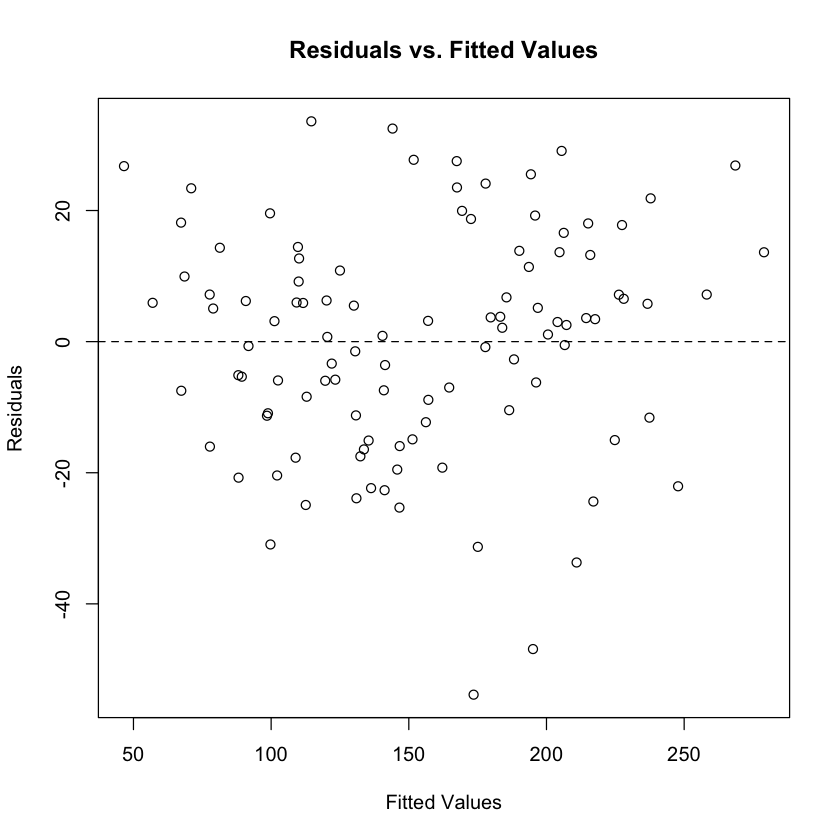

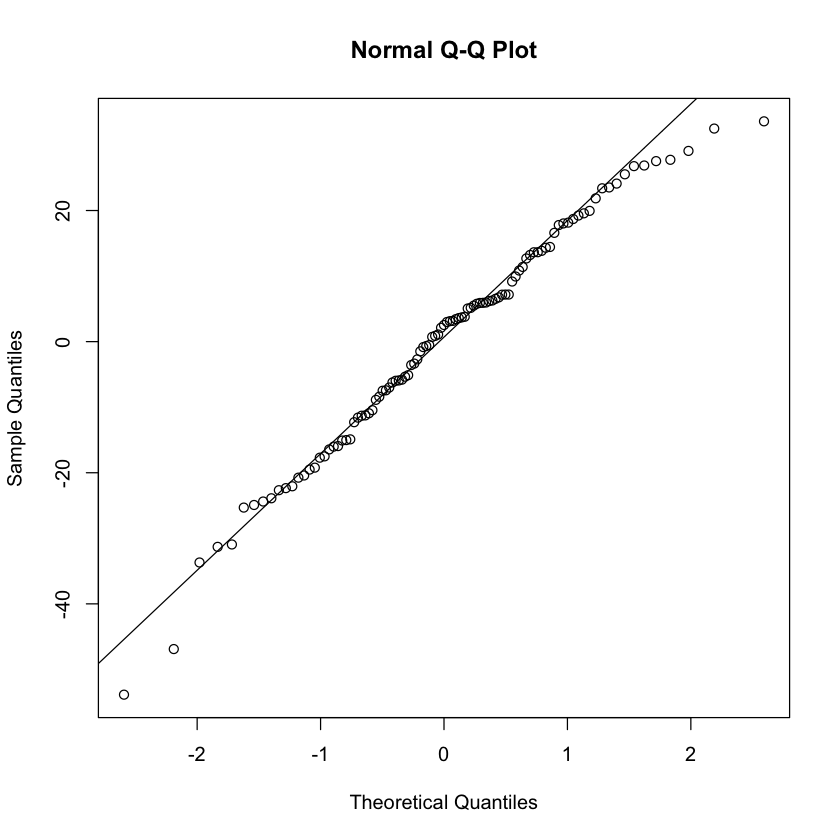

In [7]:
# fitted vs residual plot
plot(fitted(mtld_model), residuals(mtld_model), 
    main = 'Residuals vs. Fitted Values',
    xlab = 'Fitted Values', ylab = 'Residuals'
    )
abline(h = 0, lty = 2)

# qq plot of residuals
qqnorm(residuals(mtld_model))
qqline(residuals(mtld_model))

Residuals are approximately normally distributed, the Q-Q plot shows small deviation in the tails, consistent with a small number of outlying residuals (see below).

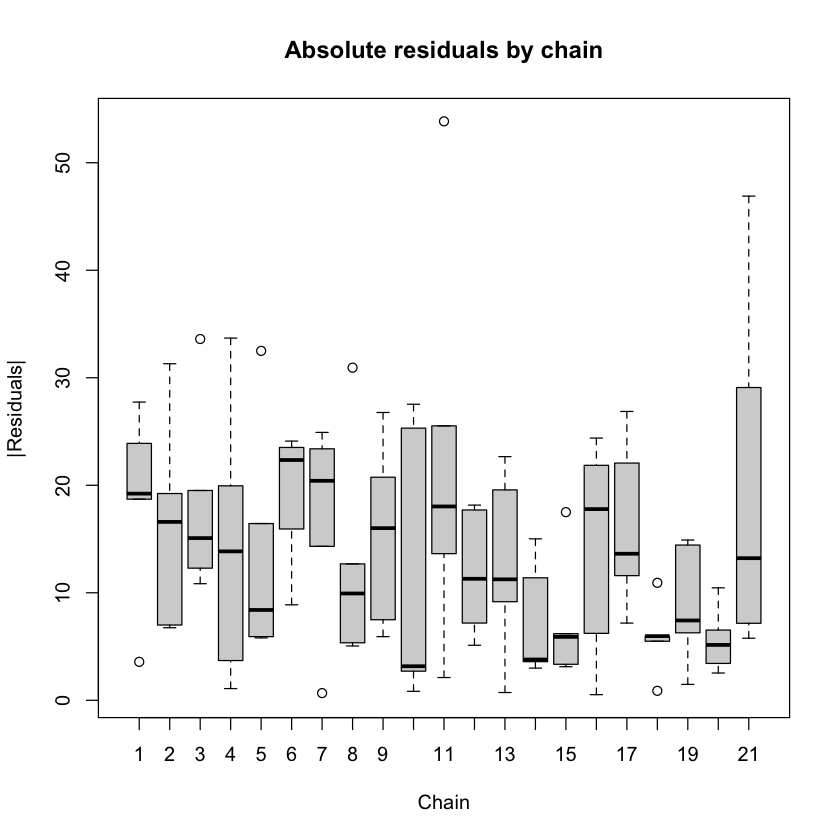

In [8]:
# absolute residuals by chain

boxplot(abs(residuals(mtld_model)) ~ texts_data$chain,
        xlab = "Chain", ylab = "|Residuals|",
        main = "Absolute residuals by chain"
)

Residual magnitude varies across chains, with chain 11 showing an extreme outlying residual and chain 21 showing comparatively high residual dispersion.

### Residual correlation

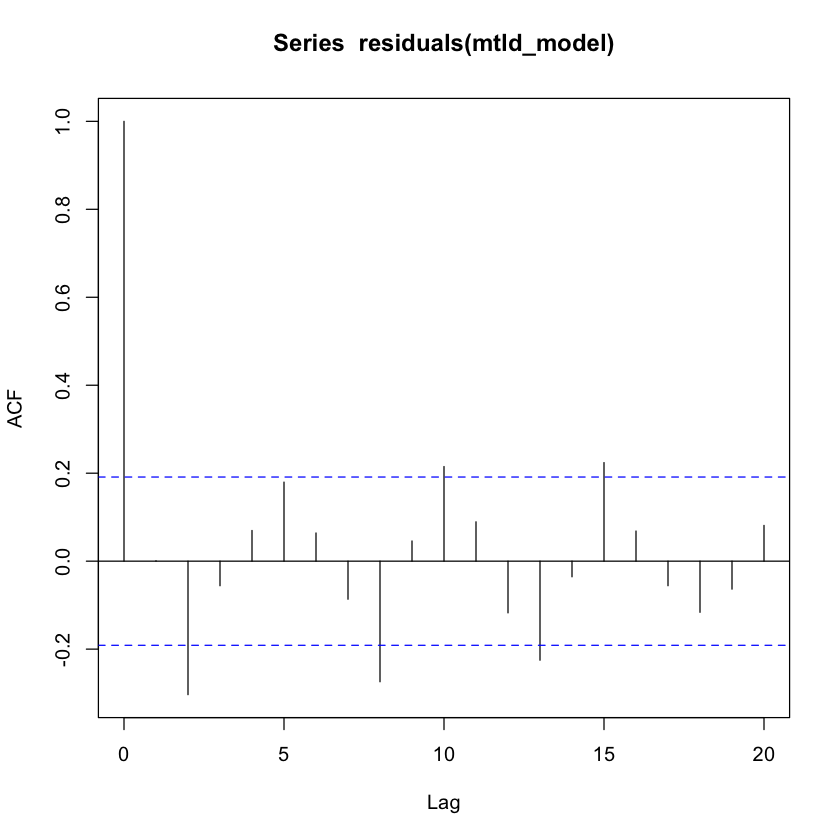

In [9]:
acf(residuals(mtld_model))

#### Exploratory: random slopes model

In [10]:
mtld_slopes_model <- lmer(mtld ~ generation_centered + (generation_centered | chain), data = texts_data)
anova(mtld_model, mtld_slopes_model)

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mtld_model,4,1001.804,1012.4203,-496.9022,993.8045,NA,NA,NA
mtld_slopes_model,6,978.795,994.7187,-483.3975,966.7950,27.00953,2,1.364442e-06


In [11]:
summary(mtld_slopes_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: mtld ~ generation_centered + (generation_centered | chain)
   Data: texts_data

REML criterion at convergence: 957.3

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.24509 -0.41346  0.05395  0.41882  2.47173 

Random effects:
 Groups   Name                Variance Std.Dev. Corr  
 chain    (Intercept)         4276.58  65.40          
          generation_centered   66.09   8.13    -0.82 
 Residual                      212.10  14.56          
Number of obs: 105, groups:  chain, 21

Fixed effects:
                    Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)          174.424     14.481  20.000  12.045 1.27e-10 ***
generation_centered  -10.401      2.039  20.000  -5.101 5.45e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.770

Chains that start with higher MTLD tend to show stronger decreases across generations, while chains that start lower tend to decreases slower.

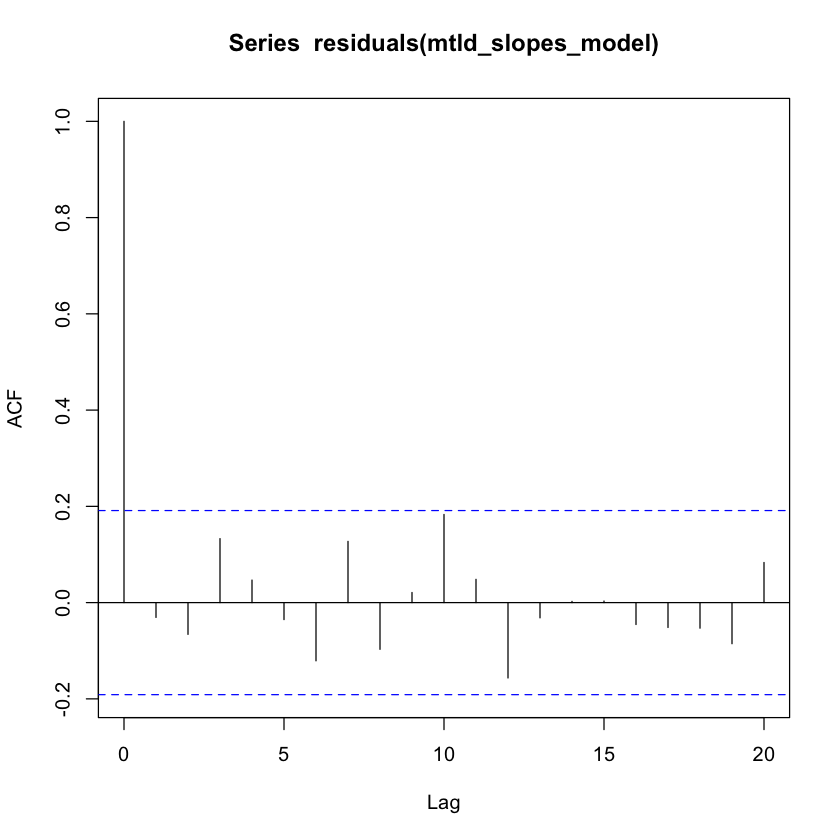

In [12]:
acf(residuals(mtld_slopes_model))

#### Exploratory: AR1 model

In [13]:
texts_data <- texts_data %>% mutate(times = as.factor(generation_centered))

mtld_model_ar <- glmmTMB(mtld ~ generation_centered + ar1(times + 0 | chain), data = texts_data)
summary(mtld_model_ar)

 Family: gaussian  ( identity )
Formula:          mtld ~ generation_centered + ar1(times + 0 | chain)
Data: texts_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    981.6     994.9    -485.8     971.6       100 

Random effects:

Conditional model:
 Groups   Name   Variance  Std.Dev.  Corr      
 chain    times0 2.798e+03 5.290e+01 0.92 (ar1)
 Residual        1.798e-09 4.241e-05           
Number of obs: 105, groups:  chain, 21

Dispersion estimate for gaussian family (sigma^2): 1.8e-09 

Conditional model:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)          174.141     11.537  15.094  < 2e-16 ***
generation_centered  -10.844      2.146  -5.054 4.33e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [14]:
anova(mtld_model, mtld_slopes_model, mtld_model_ar)

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mtld_model,4,1001.804,1012.4203,-496.9022,993.8045,NA,NA,NA
mtld_slopes_model,6,978.795,994.7187,-483.3975,966.7950,27.00953,2,1.364442e-06


# Syntactic complexity

In [18]:
dep_dist_model <- lmer(dep_dist ~ generation_centered + (1 | chain), data = texts_data)

In [19]:
summary(dep_dist_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dep_dist ~ generation_centered + (1 | chain)
   Data: texts_data

REML criterion at convergence: -26.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.5117 -0.5685  0.0716  0.5439  3.2478 

Random effects:
 Groups   Name        Variance Std.Dev.
 chain    (Intercept) 0.01948  0.1396  
 Residual             0.03116  0.1765  
Number of obs: 105, groups:  chain, 21

Fixed effects:
                     Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)          2.773238   0.042638 41.723045  65.041   <2e-16 ***
generation_centered -0.004732   0.012181 83.000001  -0.389    0.699    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.571

The linear mixed-effects model with random intercepts for chain showed no significant effect of generation on mean dependency distance, indicating that mean dependency distance remained stable across generations.

## Model diagnostics

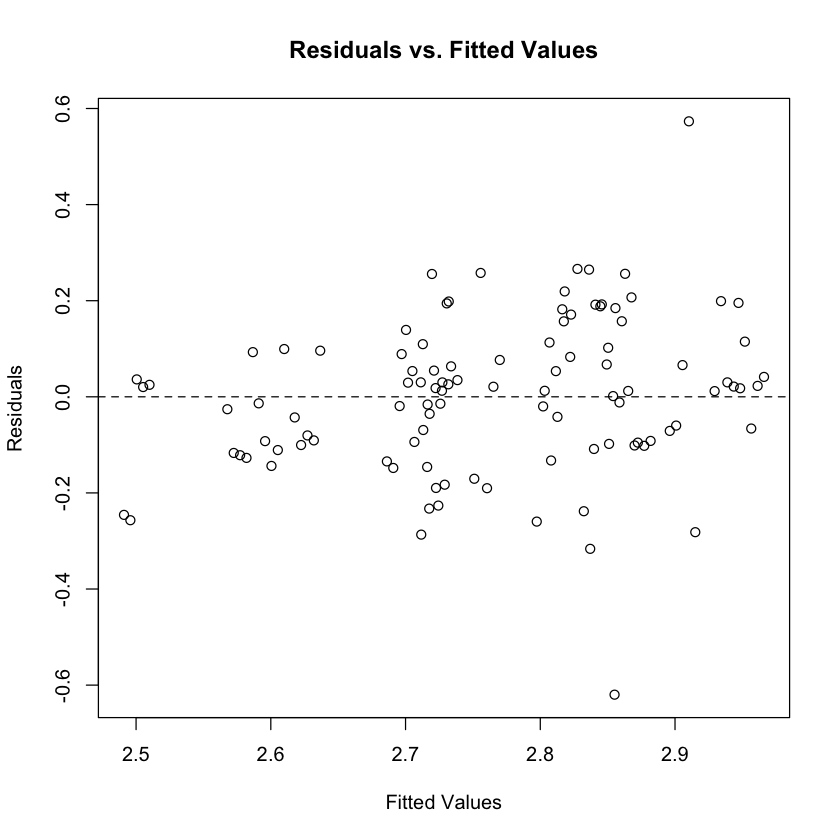

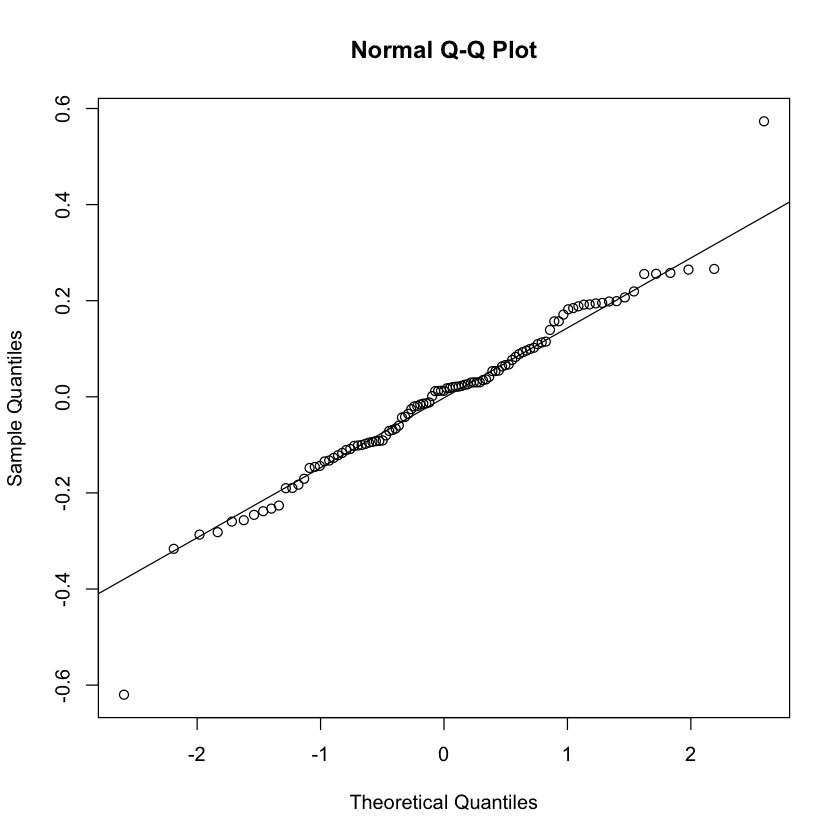

In [20]:
# fitted vs residual plot
plot(fitted(dep_dist_model), residuals(dep_dist_model), 
    main = 'Residuals vs. Fitted Values',
    xlab = 'Fitted Values', ylab = 'Residuals'
    )
abline(h = 0, lty = 2)

# qq plot of residuals
qqnorm(residuals(dep_dist_model))
qqline(residuals(dep_dist_model))

Residual diagnostics suggest no major violations of model assumptions for the dependency-distance model. Residuals are approximately normally distributed, although the Q-Q plot shows small deviation in the tails.

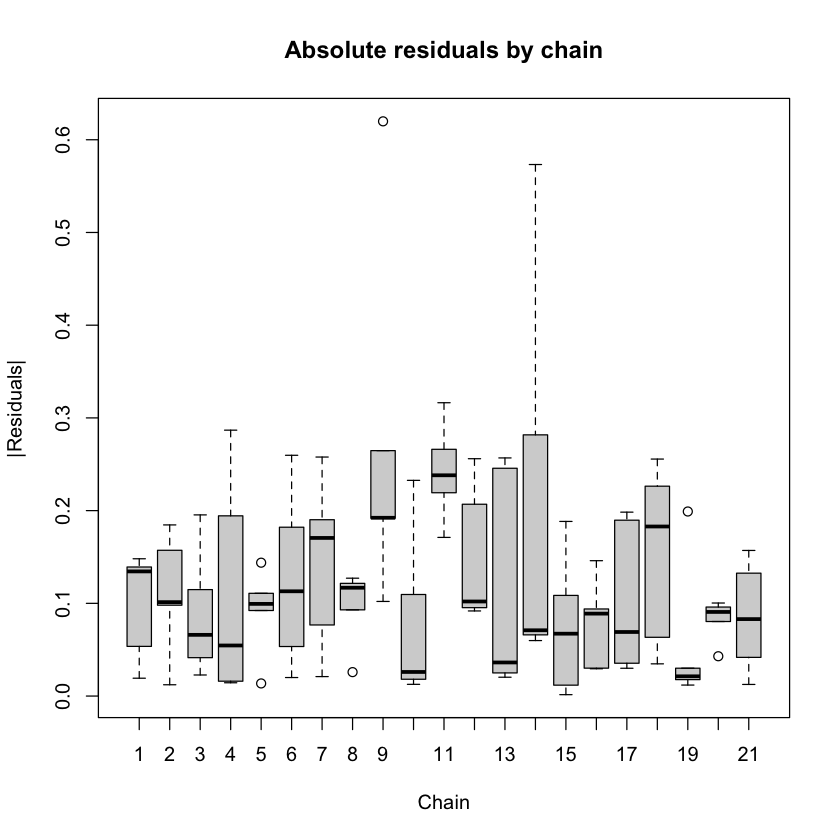

In [21]:
# absolute residuals by chain

boxplot(abs(residuals(dep_dist_model)) ~ texts_data$chain,
        xlab = "Chain", ylab = "|Residuals|",
        main = "Absolute residuals by chain"
)

### Exploratory: Additional metrics

In [22]:
# fit a model for each of the lexical_richness features (all features in the data that start with "lex_rich:") and store results in a table
lex_rich_features <- names(texts_data)[startsWith(names(texts_data), "lex_rich:")]
# drop features with no variation, which can trigger singular fits and NA vcov matrices
lex_rich_feature_sd <- sapply(texts_data[lex_rich_features], function(x) sd(x, na.rm = TRUE))
lex_rich_features <- lex_rich_features[is.finite(lex_rich_feature_sd) & lex_rich_feature_sd > 0]

# also create a cleaned version for reporting, but keep the original column names for modeling
lex_rich_clean <- texts_data %>%
    select(starts_with("lex_rich:")) %>%
    rename_with(~ gsub("lex_rich:", "", .x))

lex_rich_results <- map_dfr(lex_rich_features, function(feature) {
    formula <- as.formula(paste0('`', feature, '` ~ generation_centered + (1 | chain)'))
    model <- lmer(formula, data = texts_data)
    # if (isSingular(model, tol = 1e-4)) {
    #     return(tibble(feature = feature, term = 'generation_centered', estimate = NA_real_, std.error = NA_real_, statistic = NA_real_, p.value = NA_real_))
    # }
    tidy(model) %>%
        mutate(feature = feature)
})
lex_rich_results <- lex_rich_results %>%
    filter(term == "generation_centered") %>%
    mutate(sig = case_when(
        is.na(p.value) ~ NA_character_,
        p.value < 0.001 ~ "***",
        p.value < 0.01 ~ "**",
        p.value < 0.05 ~ "*",
        TRUE ~ "ns"
    )) %>%
    select(feature, estimate, std.error, statistic, p.value, sig)
lex_rich_results

feature,estimate,std.error,statistic,p.value,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
lex_rich:ttr,-0.0130766659,1.770581e-03,-7.385524,1.073102e-10,***
lex_rich:rttr,-0.0910720725,2.384913e-02,-3.818675,2.578173e-04,***
lex_rich:cttr,-0.0643976801,1.686388e-02,-3.818675,2.578173e-04,***
lex_rich:herdan,-0.0032709293,4.417959e-04,-7.403711,9.881219e-11,***
lex_rich:summer,-0.0019903027,2.737087e-04,-7.271610,1.797307e-10,***
lex_rich:dugast,-3.8775118378,5.440398e-01,-7.127258,3.447577e-10,***
lex_rich:maas,0.0005578044,7.789826e-05,7.160679,2.965631e-10,***
lex_rich:yulek,3.2692680955,7.614221e-01,4.293634,4.738719e-05,***
lex_rich:yulei,-4.5130371752,6.541943e-01,-6.898619,9.619036e-10,***


In [23]:
# fit a model for each of the text_desc features (all features in the data that start with "text_desc:") and store results in a table
text_desc_features <- names(texts_data)[startsWith(names(texts_data), "text_desc:")]
# drop features with no variation, which can trigger singular fits and NA vcov matrices
text_desc_feature_sd <- sapply(texts_data[text_desc_features], function(x) sd(x, na.rm = TRUE))
text_desc_features <- text_desc_features[is.finite(text_desc_feature_sd) & text_desc_feature_sd > 0]

# also create a cleaned version for reporting, but keep the original column names for modeling
text_desc_clean <- texts_data %>%
    select(starts_with("text_desc:")) %>%
    rename_with(~ gsub("text_desc:", "", .x))

text_desc_results <- map_dfr(text_desc_features, function(feature) {
    formula <- as.formula(paste0('`', feature, '` ~ generation_centered + (1 | chain)'))
    model <- lmer(formula, data = texts_data)
    # if (isSingular(model, tol = 1e-4)) {
    #     return(tibble(feature = feature, term = 'generation_centered', estimate = NA_real_, std.error = NA_real_, statistic = NA_real_, p.value = NA_real_))
    # }
    tidy(model) %>%
        mutate(feature = feature)
})
text_desc_results <- text_desc_results %>%
    filter(term == "generation_centered") %>%
    mutate(sig = case_when(
        is.na(p.value) ~ NA_character_,
        p.value < 0.001 ~ "***",
        p.value < 0.01 ~ "**",
        p.value < 0.05 ~ "*",
        TRUE ~ "ns"
    )) %>%
    select(feature, estimate, std.error, statistic, p.value, sig)
text_desc_results

boundary (singular) fit: see help('isSingular')



feature,estimate,std.error,statistic,p.value,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
text_desc:pos_prop_ADJ,-2.254991e-03,6.966184e-04,-3.23705273,1.736341e-03,**
text_desc:pos_prop_ADP,2.421602e-03,6.773191e-04,3.57527555,5.864814e-04,***
text_desc:pos_prop_ADV,9.363378e-04,5.882961e-04,1.59160976,1.152741e-01,ns
text_desc:pos_prop_AUX,2.576141e-03,6.509037e-04,3.95779094,1.588612e-04,***
text_desc:pos_prop_CCONJ,5.012200e-05,4.516773e-04,0.11096861,9.119091e-01,ns
text_desc:pos_prop_DET,1.977661e-03,6.723595e-04,2.94137510,4.233541e-03,**
text_desc:pos_prop_NOUN,-3.208717e-03,6.796589e-04,-4.72106886,9.415639e-06,***
text_desc:pos_prop_NUM,-6.943250e-05,2.304337e-04,-0.30131222,7.639300e-01,ns
text_desc:pos_prop_PART,8.920507e-04,4.519958e-04,1.97358188,5.175652e-02,ns


In [24]:
m <- lmer(`text_desc:gunning_fog` ~ generation_centered + (1 | chain), data = texts_data)
summary(m)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: `text_desc:gunning_fog` ~ generation_centered + (1 | chain)
   Data: texts_data

REML criterion at convergence: 411.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6548 -0.4750  0.0202  0.5129  4.1819 

Random effects:
 Groups   Name        Variance Std.Dev.
 chain    (Intercept) 4.066    2.016   
 Residual             1.776    1.333   
Number of obs: 105, groups:  chain, 21

Fixed effects:
                    Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)         14.67560    0.49434 26.77729  29.687   <2e-16 ***
generation_centered -0.18647    0.09197 83.00000  -2.028   0.0458 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.372

# Correctness

In [25]:
# error_model <- glmer(
#     error_count_overall ~ generation_centered + offset(log(word_count)) + (1 | chain),
#     data = texts_data,
#     family = poisson
# )

error_model <- glmmTMB(
    error_count_overall ~ generation_centered + offset(log(word_count)) + (1 | chain),
    data = texts_data,
    family = poisson
)

In [26]:
summary(error_model)

 Family: poisson  ( log )
Formula:          
error_count_overall ~ generation_centered + offset(log(word_count)) +  
    (1 | chain)
Data: texts_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    299.4     307.4    -146.7     293.4       102 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 chain  (Intercept) 0.4218   0.6494  
Number of obs: 105, groups:  chain, 21

Conditional model:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -5.69531    0.23472 -24.264  < 2e-16 ***
generation_centered  0.16676    0.06362   2.621  0.00876 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

The generalized linear mixed-effects model with a Poisson error structure, random intercepts for chain, and an offset for log word count shows a significant positive effect of generation on total error count. This indicates that, controlling for text length, errors increased across generations.

## Model diagnostics

**Overdispersion**

In a Poisson model, the variance is assumed to match the mean, so overdispersion means the data vary more than the model allows. When that happens, standard errors can be too small and p-values can look more convincing than they should.

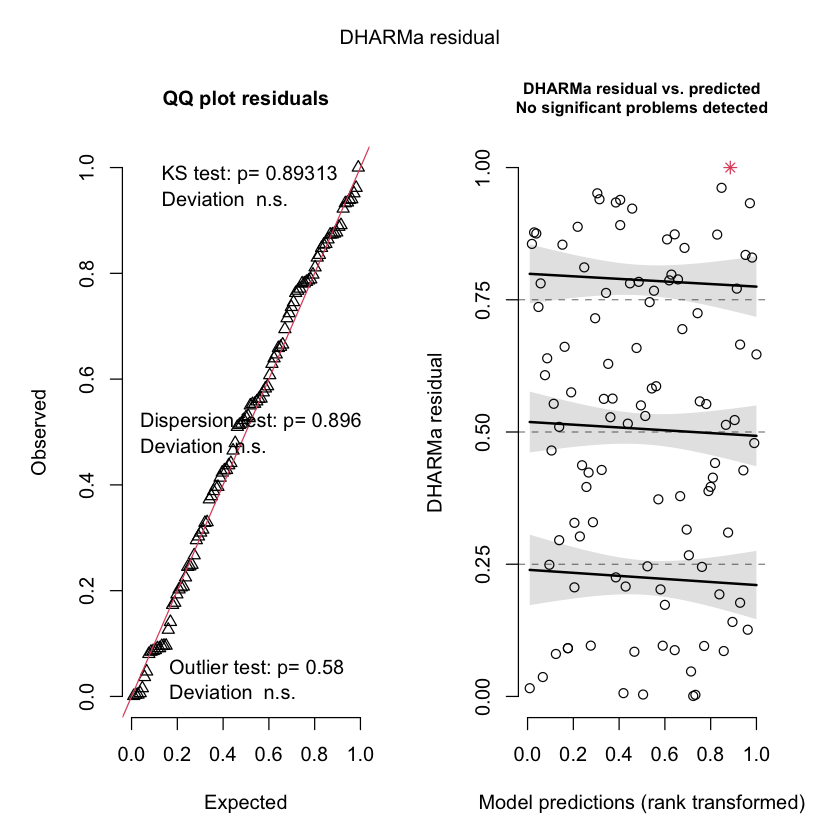


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.93268, p-value = 0.448
alternative hypothesis: greater


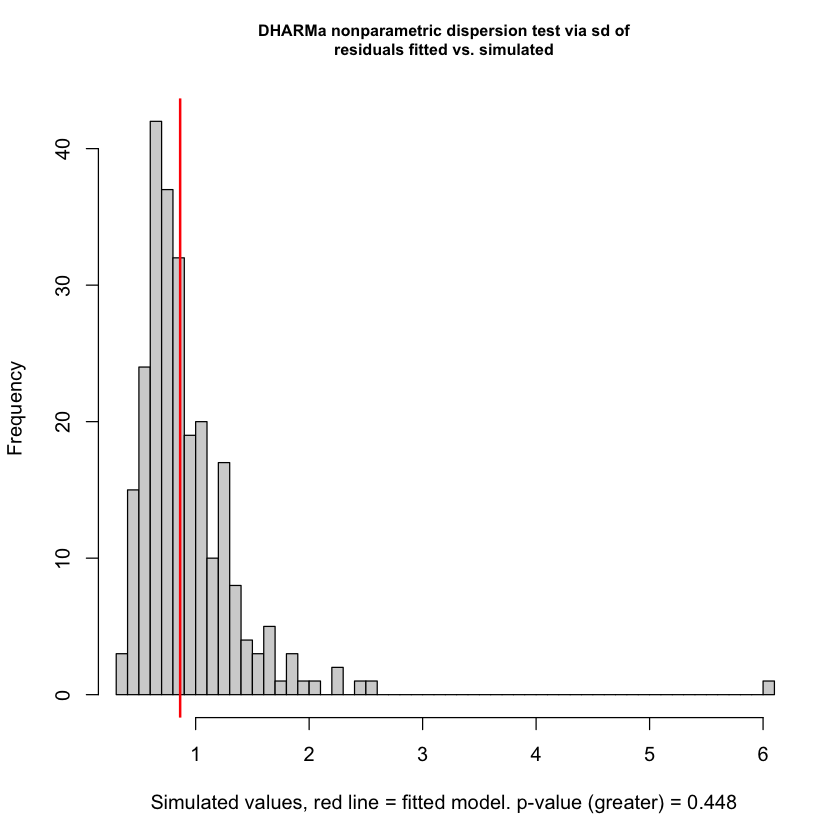


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.94349, p-value = 0.76
alternative hypothesis: two.sided


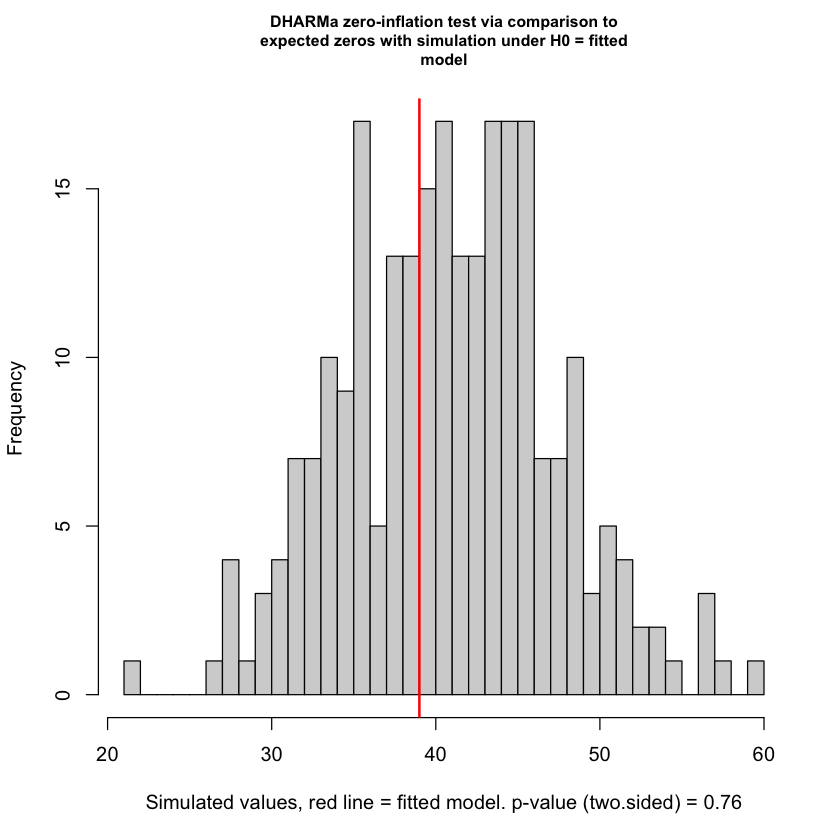

In [27]:
# use DHARMa to check whether the simulated residual spread is compatible with the fitted model via model simulation

sim_err <- simulateResiduals(
    error_model,
    re.form = NULL
)

plot(sim_err)
testDispersion(sim_err, alternative = "greater")
testZeroInflation(sim_err)

DHARMa-based model checks suggested no clear evidence that the fitted model severely violated the assumed mean-variance relationship.

# Collect p-values

In [28]:
# collect p-values for fixed effect of generation_centered from all models
models <- list(
    mtld = mtld_model,
    dep_dist = dep_dist_model,
    error_rate = error_model
)

model_summaries <- map(models, summary)

p_values <- map_dbl(models, ~ {
    s <- summary(.x)
    coef_table <- if (inherits(.x, "glmmTMB")) {
        s$coefficients$cond
    } else {
        s$coefficients
    }
    p_col <- intersect(c("Pr(>|t|)", "Pr(>|z|)"), colnames(coef_table))[1]
    coef_table["generation_centered", p_col]
})

print(p_values)

# save p-values in a file
write.csv(data.frame(model = names(p_values), p_value = p_values), "p_values_features.csv", row.names = FALSE)

        mtld     dep_dist   error_rate 
1.474660e-11 6.986294e-01 8.757619e-03 


# Plots

In [29]:
seed_data <- read_csv("../data/processed/text_metrics_with_seed.csv")

Rows: 126 Columns: 94
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): text
dbl (92): chain, generation, lex_rich:ttr, lex_rich:rttr, lex_rich:cttr, lex...
lgl  (1): text_desc:passed_quality_check

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


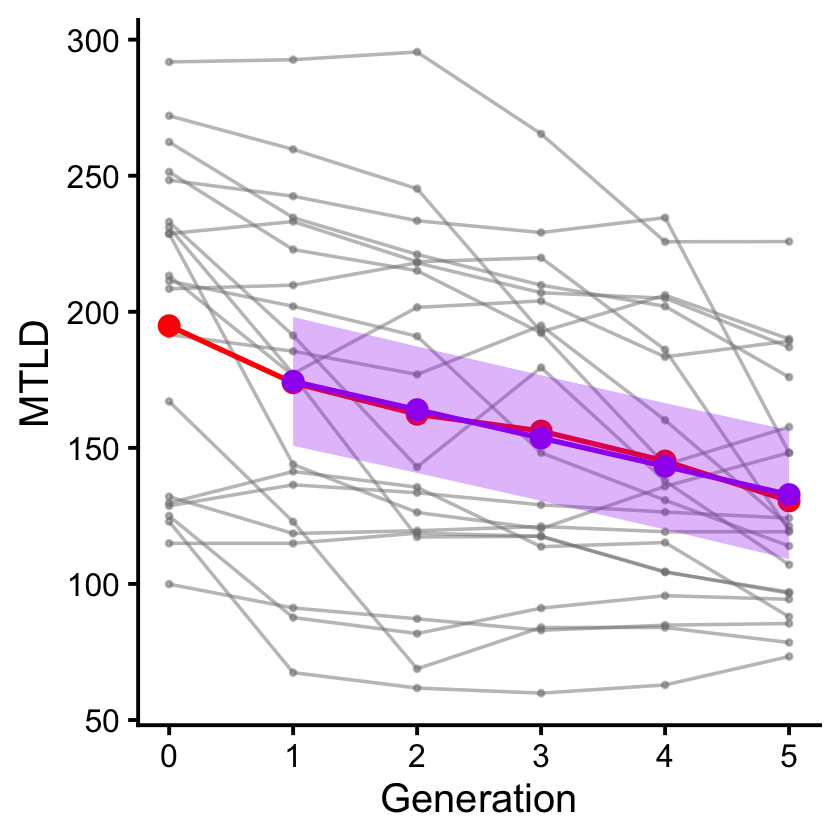

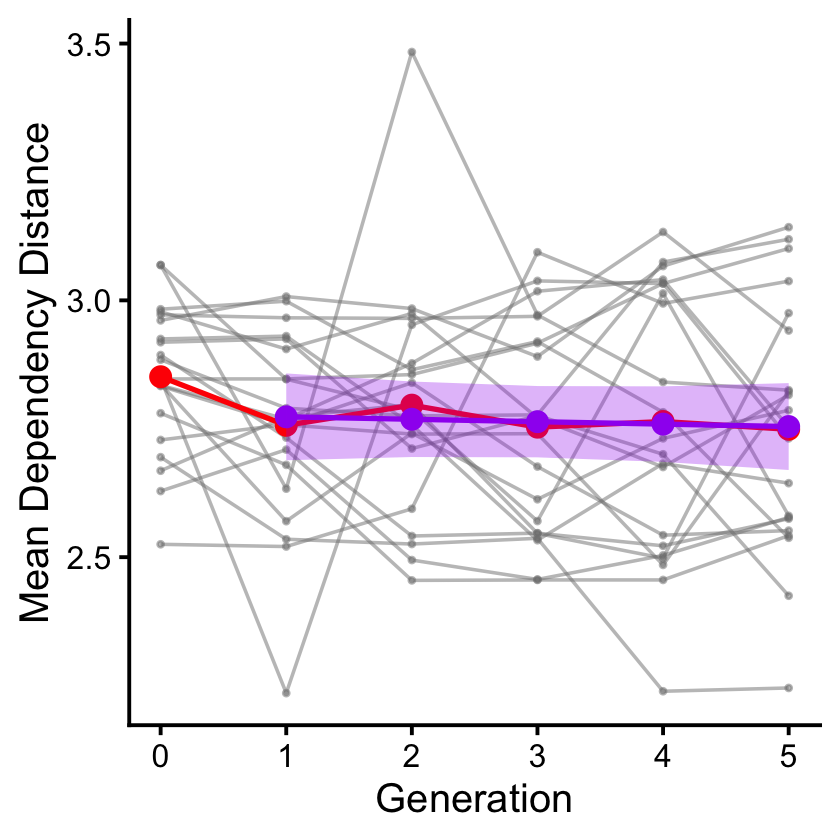

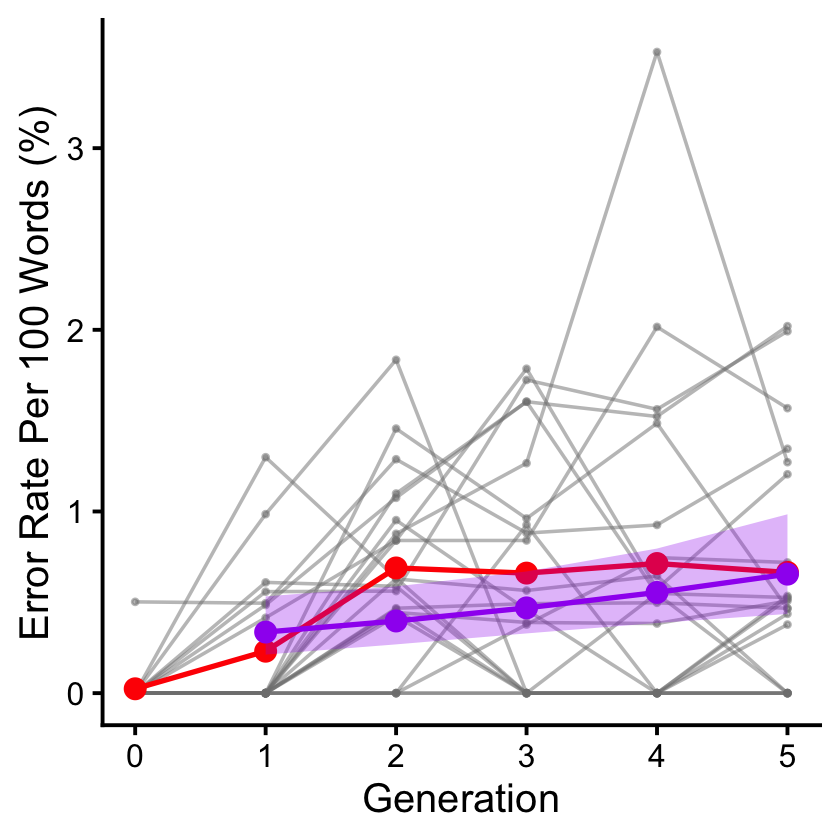

In [30]:
outcome_labels <- c(
    mtld = "MTLD",
    dep_dist = "Mean Dependency Distance",
    error_rate = "Error Rate Per 100 Words (%)"
)

effects_gen <- list(
    mtld = ggpredict(mtld_model, terms = "generation_centered") %>% as.data.frame(),
    dep_dist = ggpredict(dep_dist_model, terms = "generation_centered") %>% as.data.frame(),
    error_rate = ggpredict(error_model, terms = "generation_centered", condition = c(word_count = 1)) %>% as.data.frame() %>%
    mutate(predicted = predicted * 100,
        conf.low  = conf.low  * 100,
        conf.high = conf.high * 100)
)

x_gen_list <- map2(effects_gen, names(outcome_labels), \(df, nm) {
    df |> mutate(
        generation_num = x + 1,
        fit = predicted,
        lower = conf.low,
        upper = conf.high,
        feature = nm
    )
}) |>
set_names(names(outcome_labels))

obs_long <- texts_data_raw %>%
    mutate(
        generation_num = as.numeric(generation),
        error_rate = error_rate * 100 # scale to per 100 words
    ) %>%
    pivot_longer(
        cols = c("mtld", "dep_dist", "error_rate"),
        names_to = "feature",
        values_to = "value"
    )

seed_long <- seed_data %>%
    filter(generation == 0) %>%
    mutate(
        generation_num = 0,
        mtld = `lex_rich:mtld`, 
        dep_dist = `text_desc:dependency_distance_mean`,
        error_rate = (error_count_overall / word_count) * 100
    ) %>%
    pivot_longer(
        cols = c("mtld", "dep_dist", "error_rate"),
        names_to = "feature",
        values_to = "value"
    )

plots <- map(names(outcome_labels), \(outcome_key) {
    pred_df <- x_gen_list[[outcome_key]]
    outcome_name <- outcome_labels[[outcome_key]]

    obs <- bind_rows(
        filter(seed_long, feature == outcome_key),
        filter(obs_long,  feature == outcome_key)
    )

    obs_means <- obs %>%
        group_by(generation_num) %>%
        summarise(value = mean(value, na.rm = TRUE), .groups = "drop")


    ggplot() +
        # points for per-generation chain means
        geom_point(data = obs,
                    aes(x = generation_num, y = value),
                    size = 1, alpha = 0.5, colour = "grey50") +
        # lines linking chain means across generations (with same color as points)
        geom_line(data = obs,
                    aes(x = generation_num, y = value, group = chain),
                    size = 1, alpha = 0.5, colour = "grey50") +
        # points for per-generation means across all chains 
        geom_point(data = obs_means,
                    aes(x = generation_num, y = value),
                    colour = "red", size = 5) +
        geom_line(data = obs_means,
                    aes(x = generation_num, y = value),
                    colour = "red", linewidth=1.5) +
        # points for model estimates
        geom_point(data = pred_df, aes(x = generation_num, y = fit),
                    colour = "purple", size = 5) +
        # line for model estimates (same color as estimate points)
        geom_line(data = pred_df, aes(x = generation_num, y = fit),
                    colour = "purple", linewidth = 1.5) +
        # ribbon for CI of estimates (same color as estimate points, with alpha for transparency)
        geom_ribbon(data = pred_df, aes(x = generation_num, ymin = lower, ymax = upper),
                    fill = "purple", alpha = 0.3) +
        labs(x = "Generation", y = outcome_name) +
        theme_classic(base_size = 24)
})

# print each plot separately
for (i in seq_along(plots)) {
    print(plots[[i]])
    ggsave(paste0("figs/txt_features_model_fits/", names(models)[i], "_model_fit.pdf"), plot = plots[[i]], width = 12, height = 6)
}


# Exploratory: covariates

In [34]:
# import responses data to get demographics
responses_data <- read_csv("../data/processed/responses_combined_processed.csv")

# texts_data already contains the demographic columns needed below, so avoid a join that creates .x/.y suffixes
demog_data <- texts_data %>%
    rename(participant = ResponseId) 

Rows: 105 Columns: 43
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (27): Status, ResponseId, DistributionChannel, UserLanguage, consent, c...
dbl  (10): Progress, Duration (in seconds), Q_RecaptchaScore, age, g, c, res...
lgl   (3): Finished, Q_RecaptchaError, made_edits
dttm  (3): StartDate, EndDate, RecordedDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [35]:
# relevel factors for more meaningful interpretation
demog_data <- demog_data %>%
    mutate(
        LLM_use = factor(
            LLM_use,
            levels = c(
                "I have never used an AI chatbot / LLM",
                "I have not used any AI chatbot / LLM in the past 30 days",
                "Once in the past month",
                "2-3 times in the past month",
                "About once a week",
                "Several times per week",
                "Every day or almost every day"
            ),
            ordered = TRUE
        ),

        LLM_impact = relevel(
            factor(LLM_impact_abbrev),
            ref = "No impact"
        ),

        writing_style_pre = factor(
            writing_style_pre,
            levels = c("Not at all", "Somewhat", "A lot"),
            ordered = TRUE
        )
    )


levels(demog_data$LLM_use)
levels(demog_data$LLM_impact)
levels(demog_data$writing_style_pre)

[1] "I have never used an AI chatbot / LLM"                   
[2] "I have not used any AI chatbot / LLM in the past 30 days"
[3] "Once in the past month"                                  
[4] "2-3 times in the past month"                             
[5] "About once a week"                                       
[6] "Several times per week"                                  
[7] "Every day or almost every day"

[1] "No impact"                   "More negative than positive"
[3] "More positive than negative" "No opinion"                 
[5] "Very beneficial"             "Very detrimental"

[1] "Not at all" "Somewhat"   "A lot"

In [36]:
mtld_demogr <- lmer(
    mtld ~ generation_centered + 
    age + 
    LLM_use +
    LLM_impact +
    writing_style_pre +
    (1 | chain), 
    data = texts_data)

summary(mtld_demogr)


Correlation matrix not shown by default, as p = 16 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
mtld ~ generation_centered + age + LLM_use + LLM_impact + writing_style_pre +  
    (1 | chain)
   Data: texts_data

REML criterion at convergence: 889.1

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.00363 -0.60537 -0.03525  0.58085  1.80761 

Random effects:
 Groups   Name        Variance Std.Dev.
 chain    (Intercept) 2714.2   52.10   
 Residual              367.3   19.17   
Number of obs: 105, groups:  chain, 21

Fixed effects:
                                                                                 Estimate
(Intercept)                                                                     155.04703
generation_centered                                                             -10.00519
age                                                                              -0.05969
LLM_useAbout once a week                                                         -3.01

In [37]:
dep_dist_demogr <- lmer(
    dep_dist ~ generation_centered + 
    age + 
    LLM_use +
    LLM_impact +
    writing_style_pre +
    (1 | chain), 
    data = texts_data)

summary(dep_dist_demogr)


Correlation matrix not shown by default, as p = 16 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dep_dist ~ generation_centered + age + LLM_use + LLM_impact +  
    writing_style_pre + (1 | chain)
   Data: texts_data

REML criterion at convergence: 4.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.11286 -0.51259 -0.00254  0.59860  3.15587 

Random effects:
 Groups   Name        Variance Std.Dev.
 chain    (Intercept) 0.01682  0.1297  
 Residual             0.02920  0.1709  
Number of obs: 105, groups:  chain, 21

Fixed effects:
                                                                                 Estimate
(Intercept)                                                                      3.118573
generation_centered                                                             -0.013726
age                                                                             -0.003879
LLM_useAbout once a week                                                         0.06

In [38]:
error_demogr <- glmmTMB(
    error_count_overall ~ generation_centered + 
    offset(log(word_count)) +
    age + 
    LLM_use +
    LLM_impact +
    writing_style_pre +
    (1 | chain),
    data = texts_data,
    family = poisson
)

summary(error_demogr)

 Family: poisson  ( log )
Formula:          
error_count_overall ~ generation_centered + offset(log(word_count)) +  
    age + LLM_use + LLM_impact + writing_style_pre + (1 | chain)
Data: texts_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    315.9     361.0    -141.0     281.9        88 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 chain  (Intercept) 0.3202   0.5659  
Number of obs: 105, groups:  chain, 21

Conditional model:
                                                                                 Estimate
(Intercept)                                                                     -6.739099
generation_centered                                                              0.128624
age                                                                              0.007951
LLM_useAbout once a week                                                         0.955082
LLM_useEvery day or almost every day                                        